# Nexus AI Shape-Pull Research Notebook

This notebook keeps the current trunk:

```text
AI field
  ↓
shape / pull map
  ↓
contract-first architecture
  ↓
residue loop
  ↓
RHI system spec
```

No command line. No web dependency. No `/mnt/data` inside the notebook.

Local-root rule:

```python
ROOT = Path.cwd()
```

The notebook produces:

```text
nexus_ai_shape_pull_outputs/
  ai_shape_pull_map.csv
  component_vectors.csv
  component_cosine_similarity.csv
  ai_gap_analysis.csv
  rhi_runtime_spec.json
  rhi_contract_loop_examples.jsonl
  notebook_report.json
  figures/
```

## Core claim under test

Mainstream AI already has compression, context, gating, and readout.

The missing spine is:

$$
\boxed{\text{contract formation} \oplus \text{residue repair}}
$$

RHI runtime shape:

$$
Q \rightarrow C \rightarrow A \rightarrow O \rightarrow \Omega \rightarrow C'
$$

where:

- $Q$: prompt / injection
- $C$: missing-shape contract
- $A$: action / answer / tool call
- $O$: observation
- $\Omega$: residue
- $C'$: repaired contract


In [1]:
# ============================================================
# CONFIG
# ============================================================
from pathlib import Path

ROOT = Path.cwd()
OUTPUT_DIR = ROOT / "nexus_ai_shape_pull_outputs"
FIG_DIR = OUTPUT_DIR / "figures"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)
print("OUTPUT_DIR:", OUTPUT_DIR)


ROOT: D:\@User Data\Downloads
OUTPUT_DIR: D:\@User Data\Downloads\nexus_ai_shape_pull_outputs


In [2]:
# ============================================================
# IMPORTS
# ============================================================
import json
import math
from typing import Dict, List, Any, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("imports ready")


imports ready


## 1. Operational basis

Collapse AI into verbs instead of product labels:

$$
I \rightarrow B \rightarrow F \rightarrow G \rightarrow R
$$

- $I$: injection
- $B$: binding
- $F$: folding
- $G$: gating
- $R$: readout

Then add the missing Nexus channels:

- $C$: contract formation
- $\Omega$: residue capture
- $C'$: contract repair

The full RHI loop is:

$$
I \rightarrow B \rightarrow F \rightarrow C \rightarrow G \rightarrow R \rightarrow \Omega \rightarrow C'
$$


In [3]:
# ============================================================
# AI COMPONENT MAP
# ============================================================
# Scores are operational weights for the Nexus lens.
# 0 = absent/weak; 1 = dominant.

components = [
    {
        "component": "Transformer LLM",
        "shape": "global pull lattice",
        "nexus_readout": "attention measures gaps; softmax gates; MLP folds",
        "injection": 0.8, "binding": 1.0, "fold": 1.0, "gate": 1.0, "flow": 0.9, "readout": 1.0,
        "contract": 0.2, "residue": 0.1, "action": 0.1, "locality": 0.4, "pull": 0.9,
        "failure": "answers collapse without explicit contract; hallucination is unbounded pull"
    },
    {
        "component": "RAG / File Search",
        "shape": "external memory organ",
        "nexus_readout": "missing context is pulled from outside and folded into prompt",
        "injection": 0.7, "binding": 0.8, "fold": 0.5, "gate": 0.7, "flow": 0.9, "readout": 0.5,
        "contract": 0.4, "residue": 0.3, "action": 0.3, "locality": 0.5, "pull": 1.0,
        "failure": "retrieval can pull wrong evidence unless a contract gates it"
    },
    {
        "component": "MCP / Tools",
        "shape": "prosthetic action/interface organ",
        "nexus_readout": "model extends into callable external interfaces",
        "injection": 0.8, "binding": 0.7, "fold": 0.4, "gate": 0.8, "flow": 0.8, "readout": 0.6,
        "contract": 0.5, "residue": 0.4, "action": 1.0, "locality": 0.5, "pull": 0.8,
        "failure": "tool use without contract becomes action before shape-lock"
    },
    {
        "component": "LoRA / QLoRA",
        "shape": "low-rank groove",
        "nexus_readout": "frozen manifold plus adapter groove",
        "injection": 0.3, "binding": 0.7, "fold": 0.9, "gate": 0.5, "flow": 0.5, "readout": 0.5,
        "contract": 0.6, "residue": 0.3, "action": 0.1, "locality": 1.0, "pull": 0.6,
        "failure": "groove can overfit if residue is not recycled"
    },
    {
        "component": "Reasoning / Test-Time Compute",
        "shape": "recursive pull before readout",
        "nexus_readout": "more internal folds are spent before collapse",
        "injection": 0.8, "binding": 0.9, "fold": 1.0, "gate": 0.9, "flow": 0.8, "readout": 0.9,
        "contract": 0.4, "residue": 0.4, "action": 0.2, "locality": 0.4, "pull": 0.9,
        "failure": "reasoning wanders if not contract-guided"
    },
    {
        "component": "Agents",
        "shape": "recursive action loop",
        "nexus_readout": "LLM chooses, acts, observes, repeats",
        "injection": 0.8, "binding": 0.8, "fold": 0.8, "gate": 0.9, "flow": 0.9, "readout": 0.8,
        "contract": 0.5, "residue": 0.6, "action": 1.0, "locality": 0.5, "pull": 0.8,
        "failure": "action loop lacks stable Ω-to-contract repair"
    },
    {
        "component": "Mamba / State-Space Models",
        "shape": "selective flow channel",
        "nexus_readout": "state is carried forward by selective gates instead of full mirror lattice",
        "injection": 0.7, "binding": 0.8, "fold": 0.8, "gate": 0.8, "flow": 1.0, "readout": 0.8,
        "contract": 0.2, "residue": 0.2, "action": 0.1, "locality": 0.6, "pull": 0.6,
        "failure": "long flow can preserve state without explicit contract semantics"
    },
    {
        "component": "Diffusion Models",
        "shape": "noise-to-form collapse",
        "nexus_readout": "iterative denoising pulls latent structure into visible form",
        "injection": 0.7, "binding": 0.8, "fold": 0.9, "gate": 0.6, "flow": 0.7, "readout": 1.0,
        "contract": 0.3, "residue": 0.2, "action": 0.2, "locality": 0.4, "pull": 0.9,
        "failure": "prompt may under-specify the shape; image looks right but violates hidden contract"
    },
    {
        "component": "Safety / Alignment",
        "shape": "boundary critic",
        "nexus_readout": "filters collapse through policy and risk gates",
        "injection": 0.5, "binding": 0.5, "fold": 0.5, "gate": 1.0, "flow": 0.4, "readout": 0.7,
        "contract": 0.7, "residue": 0.7, "action": 0.4, "locality": 0.4, "pull": 0.4,
        "failure": "policy without operational contract becomes surface refusal or surface compliance"
    },
    {
        "component": "Hardware / Accelerators",
        "shape": "substrate adapts to fold pressure",
        "nexus_readout": "memory bandwidth, precision, and caches bend toward model geometry",
        "injection": 0.2, "binding": 0.4, "fold": 0.8, "gate": 0.4, "flow": 1.0, "readout": 0.4,
        "contract": 0.1, "residue": 0.1, "action": 0.1, "locality": 0.9, "pull": 0.3,
        "failure": "faster collapse does not fix wrong shape"
    },
    {
        "component": "RHI Slot-Builder",
        "shape": "missing-shape contract generator",
        "nexus_readout": "prompt emits contract before answer selection",
        "injection": 0.9, "binding": 0.9, "fold": 0.8, "gate": 0.8, "flow": 0.7, "readout": 0.7,
        "contract": 1.0, "residue": 0.6, "action": 0.2, "locality": 1.0, "pull": 0.9,
        "failure": "contract can leak boundary terms into domain carrier"
    },
    {
        "component": "RHI KRRB Resolver",
        "shape": "branch, audit, residue, repair",
        "nexus_readout": "selection is gated by support and residue, not direct answer confidence",
        "injection": 0.8, "binding": 0.8, "fold": 0.8, "gate": 1.0, "flow": 0.8, "readout": 0.8,
        "contract": 1.0, "residue": 1.0, "action": 0.6, "locality": 0.9, "pull": 0.8,
        "failure": "too-safe gates freeze back to base; too-loose gates create hurt"
    },
]

ai_df = pd.DataFrame(components)
ai_df.to_csv(OUTPUT_DIR / "ai_shape_pull_map.csv", index=False)
display(ai_df)


,component,shape,nexus_readout,injection,binding,fold,gate,flow,readout,contract,residue,action,locality,pull,failure
0,Transformer LLM,global pull lattice,attention measures gaps; softmax gates; MLP folds,0.8,1.0,1.0,1.0,0.9,1.0,0.2,0.1,0.1,0.4,0.9,answers collapse without explicit contract; ha...
1,RAG / File Search,external memory organ,missing context is pulled from outside and fol...,0.7,0.8,0.5,0.7,0.9,0.5,0.4,0.3,0.3,0.5,1.0,retrieval can pull wrong evidence unless a con...
2,MCP / Tools,prosthetic action/interface organ,model extends into callable external interfaces,0.8,0.7,0.4,0.8,0.8,0.6,0.5,0.4,1.0,0.5,0.8,tool use without contract becomes action befor...
3,LoRA / QLoRA,low-rank groove,frozen manifold plus adapter groove,0.3,0.7,0.9,0.5,0.5,0.5,0.6,0.3,0.1,1.0,0.6,groove can overfit if residue is not recycled
4,Reasoning / Test-Time Compute,recursive pull before readout,more internal folds are spent before collapse,0.8,0.9,1.0,0.9,0.8,0.9,0.4,0.4,0.2,0.4,0.9,reasoning wanders if not contract-guided
5,Agents,recursive action loop,"LLM chooses, acts, observes, repeats",0.8,0.8,0.8,0.9,0.9,0.8,0.5,0.6,1.0,0.5,0.8,action loop lacks stable Ω-to-contract repair
6,Mamba / State-Space Models,selective flow channel,state is carried forward by selective gates in...,0.7,0.8,0.8,0.8,1.0,0.8,0.2,0.2,0.1,0.6,0.6,long flow can preserve state without explicit ...
7,Diffusion Models,noise-to-form collapse,iterative denoising pulls latent structure int...,0.7,0.8,0.9,0.6,0.7,1.0,0.3,0.2,0.2,0.4,0.9,prompt may under-specify the shape; image look...
8,Safety / Alignment,boundary critic,filters collapse through policy and risk gates,0.5,0.5,0.5,1.0,0.4,0.7,0.7,0.7,0.4,0.4,0.4,policy without operational contract becomes su...
9,Hardware / Accelerators,substrate adapts to fold pressure,"memory bandwidth, precision, and caches bend t...",0.2,0.4,0.8,0.4,1.0,0.4,0.1,0.1,0.1,0.9,0.3,faster collapse does not fix wrong shape


## 2. Vectorizing the field

Each component becomes a vector over operational axes:

$$
v = (I,B,F,G,\text{flow},R,C,\Omega,A,L,P)
$$

Then ask:

- Which systems are close in shape?
- Which systems lack contract?
- Which systems lack residue?
- Which systems act before contract?


In [4]:
# ============================================================
# VECTOR ANALYSIS
# ============================================================
VECTOR_COLS = [
    "injection", "binding", "fold", "gate", "flow", "readout",
    "contract", "residue", "action", "locality", "pull"
]

vec_df = ai_df[["component"] + VECTOR_COLS].copy()
vec_df.to_csv(OUTPUT_DIR / "component_vectors.csv", index=False)

def cosine(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    den = np.linalg.norm(a) * np.linalg.norm(b)
    return float(np.dot(a, b) / den) if den else 0.0

names = vec_df["component"].tolist()
X = vec_df[VECTOR_COLS].values

sim = np.zeros((len(names), len(names)))
for i in range(len(names)):
    for j in range(len(names)):
        sim[i, j] = cosine(X[i], X[j])

sim_df = pd.DataFrame(sim, index=names, columns=names)
sim_df.to_csv(OUTPUT_DIR / "component_cosine_similarity.csv")
display(sim_df.round(3))


,Transformer LLM,RAG / File Search,MCP / Tools,LoRA / QLoRA,Reasoning / Test-Time Compute,Agents,Mamba / State-Space Models,Diffusion Models,Safety / Alignment,Hardware / Accelerators,RHI Slot-Builder,RHI KRRB Resolver
Transformer LLM,1.000,0.944,0.862,0.867,0.986,0.901,0.982,0.984,0.846,0.834,0.891,0.861
RAG / File Search,0.944,1.000,0.940,0.882,0.961,0.941,0.952,0.947,0.867,0.827,0.942,0.922
MCP / Tools,0.862,0.940,1.000,0.811,0.899,0.985,0.877,0.880,0.899,0.746,0.895,0.932
LoRA / QLoRA,0.867,0.882,0.811,1.000,0.898,0.852,0.898,0.889,0.847,0.898,0.955,0.916
Reasoning / Test-Time Compute,0.986,0.961,0.899,0.898,1.000,0.940,0.975,0.988,0.903,0.826,0.937,0.923
Agents,0.901,0.941,0.985,0.852,0.940,1.000,0.913,0.920,0.928,0.792,0.911,0.953
Mamba / State-Space Models,0.982,0.952,0.877,0.898,0.975,0.913,1.000,0.966,0.857,0.906,0.915,0.891
Diffusion Models,0.984,0.947,0.880,0.889,0.988,0.920,0.966,1.000,0.855,0.825,0.915,0.888
Safety / Alignment,0.846,0.867,0.899,0.847,0.903,0.928,0.857,0.855,1.000,0.707,0.923,0.971
Hardware / Accelerators,0.834,0.827,0.746,0.898,0.826,0.792,0.906,0.825,0.707,1.000,0.818,0.794


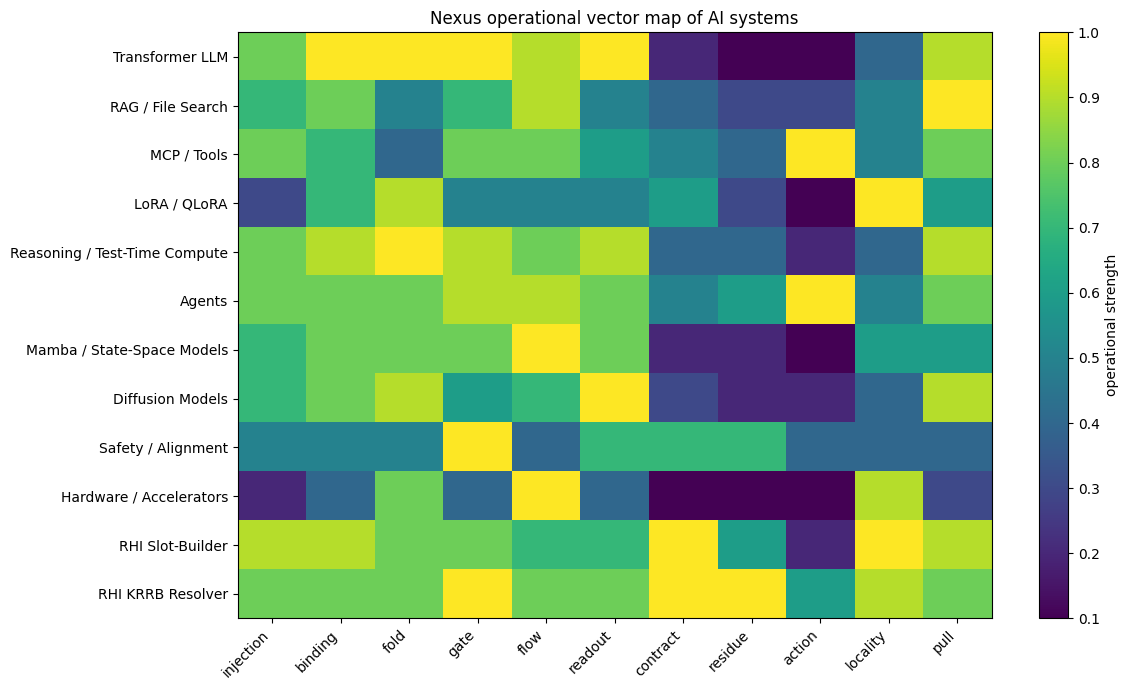

In [5]:
# ============================================================
# PLOT: OPERATIONAL HEATMAP
# ============================================================
fig, ax = plt.subplots(figsize=(12, 7))
im = ax.imshow(vec_df[VECTOR_COLS].values, aspect="auto")
ax.set_xticks(range(len(VECTOR_COLS)))
ax.set_xticklabels(VECTOR_COLS, rotation=45, ha="right")
ax.set_yticks(range(len(vec_df)))
ax.set_yticklabels(vec_df["component"])
ax.set_title("Nexus operational vector map of AI systems")
fig.colorbar(im, ax=ax, label="operational strength")
fig.tight_layout()
fig.savefig(FIG_DIR / "ai_operational_heatmap.png", dpi=160)
plt.show()


In [6]:
# ============================================================
# GAP ANALYSIS
# ============================================================
gap_df = ai_df.copy()
gap_df["contract_gap"] = 1.0 - gap_df["contract"]
gap_df["residue_gap"] = 1.0 - gap_df["residue"]
gap_df["unsafe_action_pressure"] = gap_df["action"] * gap_df["contract_gap"]
gap_df["hallucination_pressure"] = gap_df["pull"] * gap_df["contract_gap"]
gap_df["repair_deficit"] = gap_df["gate"] * gap_df["residue_gap"]

gap_cols = [
    "component", "shape", "contract_gap", "residue_gap",
    "unsafe_action_pressure", "hallucination_pressure", "repair_deficit",
    "failure"
]

gap_view = gap_df[gap_cols].sort_values(
    ["hallucination_pressure", "unsafe_action_pressure", "repair_deficit"],
    ascending=False
)

gap_view.to_csv(OUTPUT_DIR / "ai_gap_analysis.csv", index=False)
display(gap_view)


,component,shape,contract_gap,residue_gap,unsafe_action_pressure,hallucination_pressure,repair_deficit,failure
0,Transformer LLM,global pull lattice,0.8,0.9,0.08,0.72,0.90,answers collapse without explicit contract; ha...
7,Diffusion Models,noise-to-form collapse,0.7,0.8,0.14,0.63,0.48,prompt may under-specify the shape; image look...
1,RAG / File Search,external memory organ,0.6,0.7,0.18,0.60,0.49,retrieval can pull wrong evidence unless a con...
4,Reasoning / Test-Time Compute,recursive pull before readout,0.6,0.6,0.12,0.54,0.54,reasoning wanders if not contract-guided
6,Mamba / State-Space Models,selective flow channel,0.8,0.8,0.08,0.48,0.64,long flow can preserve state without explicit ...
2,MCP / Tools,prosthetic action/interface organ,0.5,0.6,0.50,0.40,0.48,tool use without contract becomes action befor...
5,Agents,recursive action loop,0.5,0.4,0.50,0.40,0.36,action loop lacks stable Ω-to-contract repair
9,Hardware / Accelerators,substrate adapts to fold pressure,0.9,0.9,0.09,0.27,0.36,faster collapse does not fix wrong shape
3,LoRA / QLoRA,low-rank groove,0.4,0.7,0.04,0.24,0.35,groove can overfit if residue is not recycled
8,Safety / Alignment,boundary critic,0.3,0.3,0.12,0.12,0.30,policy without operational contract becomes su...


## 3. Pull-field collapse model

A normal system does:

$$
Q \rightarrow A
$$

A Nexus/RHI system does:

$$
Q \rightarrow C \rightarrow A
$$

Candidate score:

$$
\Psi(a_i)=w_b S_b(a_i)+w_c S_c(a_i)+w_d S_d(a_i)-w_f S_f(a_i)+w_w S_w(a_i)
$$

Collapse only if support and margin both clear the gates.


In [7]:
# ============================================================
# CONTRACT-GATED CANDIDATE COLLAPSE DEMO
# ============================================================
def candidate_score(row, weights=None):
    if weights is None:
        weights = {
            "base": 0.45,
            "contract": 0.25,
            "domain": 0.20,
            "forbidden": 0.30,
            "witness": 0.20,
        }
    return (
        weights["base"] * row["base_support"]
        + weights["contract"] * row["contract_support"]
        + weights["domain"] * row["domain_support"]
        - weights["forbidden"] * row["forbidden_penalty"]
        + weights["witness"] * row["witness_support"]
    )

demo_candidates = pd.DataFrame([
    {
        "candidate": "surface answer",
        "base_support": 0.88,
        "contract_support": 0.32,
        "domain_support": 0.28,
        "forbidden_penalty": 0.75,
        "witness_support": 0.25,
    },
    {
        "candidate": "contract-fit answer",
        "base_support": 0.76,
        "contract_support": 0.91,
        "domain_support": 0.87,
        "forbidden_penalty": 0.10,
        "witness_support": 0.83,
    },
    {
        "candidate": "nearby Nexus decoy",
        "base_support": 0.82,
        "contract_support": 0.61,
        "domain_support": 0.55,
        "forbidden_penalty": 0.58,
        "witness_support": 0.49,
    },
])

demo_candidates["psi"] = demo_candidates.apply(candidate_score, axis=1)
demo_candidates = demo_candidates.sort_values("psi", ascending=False).reset_index(drop=True)

margin = demo_candidates.loc[0, "psi"] - demo_candidates.loc[1, "psi"]
support = int((demo_candidates.loc[0, ["base_support", "contract_support", "domain_support", "witness_support"]] > 0.70).sum())
collapse = bool(support >= 3 and margin >= 0.05)

display(demo_candidates)
print("winner:", demo_candidates.loc[0, "candidate"])
print("support:", support)
print("margin:", round(float(margin), 4))
print("collapse:", collapse)


,candidate,base_support,contract_support,domain_support,forbidden_penalty,witness_support,psi
0,contract-fit answer,0.76,0.91,0.87,0.10,0.83,0.8795
1,nearby Nexus decoy,0.82,0.61,0.55,0.58,0.49,0.5555
2,surface answer,0.88,0.32,0.28,0.75,0.25,0.3570


winner: contract-fit answer
support: 4
margin: 0.324
collapse: True


C:\Users\Developer\AppData\Local\Temp\ipykernel_51336\2235559896.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(demo_candidates["candidate"], rotation=20, ha="right")


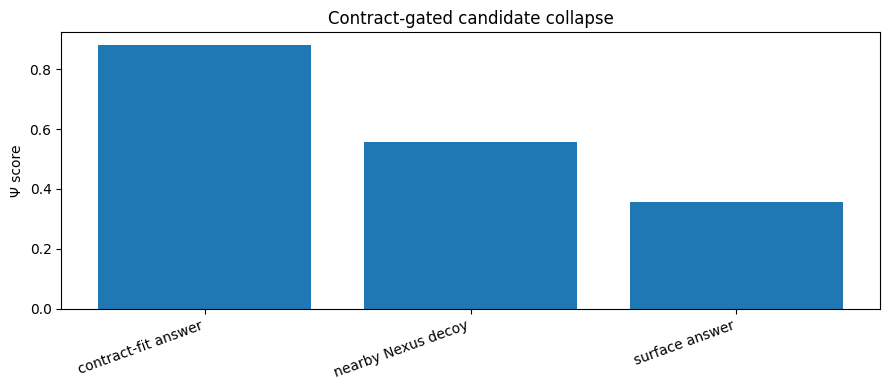

In [8]:
# ============================================================
# VISUALIZE CANDIDATE COLLAPSE
# ============================================================
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(demo_candidates["candidate"], demo_candidates["psi"])
ax.set_title("Contract-gated candidate collapse")
ax.set_ylabel("Ψ score")
ax.set_xticklabels(demo_candidates["candidate"], rotation=20, ha="right")
fig.tight_layout()
fig.savefig(FIG_DIR / "contract_gated_candidate_collapse.png", dpi=160)
plt.show()


## 4. RHI runtime architecture

```text
prompt
  ↓
slot-builder LoRA
  ↓
operational critic
  ↓
KRRB resolver
  ↓
answer/tool/refusal/Ω
  ↓
residue memory
  ↓
next contract
```

Formal runtime:

$$
RHI=(M_0, \Delta W_{slot}, A_{critic}, KRRB, \Omega_{memory})
$$


In [9]:
# ============================================================
# RHI SYSTEM SPEC
# ============================================================
rhi_spec = {
    "name": "Recursive Harmonic Intelligence Runtime",
    "version": "trunk_spec_01",
    "runtime_loop": [
        {"step": "prompt", "symbol": "Q", "operation": "kinetic injection"},
        {"step": "slot_builder", "symbol": "C", "operation": "generate missing-shape contract"},
        {"step": "operational_critic", "symbol": "A(C)", "operation": "score need/function/boundary/trap/collapse"},
        {"step": "candidate_generation", "symbol": "B", "operation": "produce or retrieve candidate continuations"},
        {"step": "KRRB", "symbol": "Ψ/Ω", "operation": "collapse, refuse, or return residue"},
        {"step": "residue_memory", "symbol": "Ω", "operation": "capture hurt, leak, ambiguity, missing carrier"},
        {"step": "contract_repair", "symbol": "C'", "operation": "backpatch contract and train next groove"},
    ],
    "contract_schema": [
        "family_class", "domain_carrier", "forbidden_neighbor_carrier",
        "boundary_conditions", "preserved_function", "failure_modes",
        "witness_readout", "residue"
    ],
    "audit_dimensions": ["F_need", "F_function", "F_boundary", "F_trap", "F_collapse"],
    "current_artifacts": {
        "slot_builder_adapter": "slot_builder_lora_v1/",
        "eval_outputs": "slot_builder_lora_v1_eval/",
        "shape_pull_outputs": str(OUTPUT_DIR),
    },
    "trunk_status": {
        "slot_builder_valid_json": "24/24 in last eval",
        "slot_builder_complete_contracts": "24/24 in last eval",
        "slot_builder_exact_cleaned": "16/24 in last eval",
        "next_action": "classify failures into model failure vs scoring/normalization artifact",
    }
}

(OUTPUT_DIR / "rhi_runtime_spec.json").write_text(json.dumps(rhi_spec, indent=2), encoding="utf-8")
print(json.dumps(rhi_spec, indent=2))


{
  "name": "Recursive Harmonic Intelligence Runtime",
  "version": "trunk_spec_01",
  "runtime_loop": [
    {
      "step": "prompt",
      "symbol": "Q",
      "operation": "kinetic injection"
    },
    {
      "step": "slot_builder",
      "symbol": "C",
      "operation": "generate missing-shape contract"
    },
    {
      "step": "operational_critic",
      "symbol": "A(C)",
      "operation": "score need/function/boundary/trap/collapse"
    },
    {
      "step": "candidate_generation",
      "symbol": "B",
      "operation": "produce or retrieve candidate continuations"
    },
    {
      "step": "KRRB",
      "symbol": "\u03a8/\u03a9",
      "operation": "collapse, refuse, or return residue"
    },
    {
      "step": "residue_memory",
      "symbol": "\u03a9",
      "operation": "capture hurt, leak, ambiguity, missing carrier"
    },
    {
      "step": "contract_repair",
      "symbol": "C'",
      "operation": "backpatch contract and train next groove"
    }
  ],
  "contra

## 5. Residue taxonomy

Every failure becomes typed $\Omega$.

| Ω type | Meaning | Repair |
|---|---|---|
| carrier_leak | boundary/forbidden terms leak into domain carrier | cleanup or better negative carrier |
| thin_domain | domain carrier under-specified | add prompt-specific operational tokens |
| generic_function | preserved function is vague | force verb-specific readout |
| trap_failure | surface label wins over operation | strengthen forbidden neighbor |
| collapse_split | multiple interpretations survive | add witness/readout constraint |
| base_freeze | safe branch returns base everywhere | relax gates, raise evidence |
| unsafe_hurt | override breaks correct base answer | backpatch false override |


In [10]:
# ============================================================
# RESIDUE EXAMPLES FROM CURRENT TRUNK
# ============================================================
residue_examples = [
    {
        "case_id": "adv_api_01",
        "omega": "carrier_leak",
        "symptom": "persistence/retries/errors leaked into domain_carrier",
        "repair": "remove hidden machinery from domain carrier while preserving forbidden carrier",
        "status": "cleanup fixed in eval",
    },
    {
        "case_id": "adv_coupler_01",
        "omega": "operational_function_mismatch",
        "symptom": "generated maintained rotational motion instead of radial compression enabling transmission",
        "repair": "contract must distinguish binding method from transmitted function",
        "status": "needs contract teaching row",
    },
    {
        "case_id": "adv_ping_01",
        "omega": "thin_family_and_domain",
        "symptom": "family collapsed to math instead of operational closure of ping beacon shaped math tested",
        "repair": "preserve ping/beacon/tested carrier and reject semantic/database mysticism",
        "status": "needs contract teaching row",
    },
    {
        "case_id": "adv_socket_01",
        "omega": "relation_carrier_loss",
        "symptom": "lost plug/works/its/meet/allowed/relation carrier",
        "repair": "force relational geometry tokens into domain carrier",
        "status": "needs contract teaching row",
    },
    {
        "case_id": "adv_weight_01",
        "omega": "wrong_abstraction_level",
        "symptom": "model generated generic operational collapse instead of LLM weights as field, not database lookup",
        "repair": "teach LLM weight field vs lookup-table boundary",
        "status": "needs contract teaching row",
    },
]

with (OUTPUT_DIR / "rhi_contract_loop_examples.jsonl").open("w", encoding="utf-8") as f:
    for r in residue_examples:
        f.write(json.dumps(r, ensure_ascii=False) + "\n")

residue_df = pd.DataFrame(residue_examples)
display(residue_df)


,case_id,omega,symptom,repair,status
0,adv_api_01,carrier_leak,persistence/retries/errors leaked into domain_...,remove hidden machinery from domain carrier wh...,cleanup fixed in eval
1,adv_coupler_01,operational_function_mismatch,generated maintained rotational motion instead...,contract must distinguish binding method from ...,needs contract teaching row
2,adv_ping_01,thin_family_and_domain,family collapsed to math instead of operationa...,preserve ping/beacon/tested carrier and reject...,needs contract teaching row
3,adv_socket_01,relation_carrier_loss,lost plug/works/its/meet/allowed/relation carrier,force relational geometry tokens into domain c...,needs contract teaching row
4,adv_weight_01,wrong_abstraction_level,model generated generic operational collapse i...,teach LLM weight field vs lookup-table boundary,needs contract teaching row


In [11]:
# ============================================================
# SAVE FINAL REPORT TABLES
# ============================================================
report = {
    "notebook": "nexus_ai_shape_pull_research_notebook",
    "root": str(ROOT),
    "output_dir": str(OUTPUT_DIR),
    "generated_files": [
        "ai_shape_pull_map.csv",
        "component_vectors.csv",
        "component_cosine_similarity.csv",
        "ai_gap_analysis.csv",
        "rhi_runtime_spec.json",
        "rhi_contract_loop_examples.jsonl",
        "figures/ai_operational_heatmap.png",
        "figures/contract_gated_candidate_collapse.png",
    ],
    "collapse": "Mainstream AI has compression/context/gating/readout. RHI adds contract formation and residue repair.",
}

(OUTPUT_DIR / "notebook_report.json").write_text(json.dumps(report, indent=2), encoding="utf-8")

print("Saved files:")
for p in sorted(OUTPUT_DIR.rglob("*")):
    if p.is_file():
        print(" -", p.relative_to(OUTPUT_DIR))


Saved files:
 - ai_gap_analysis.csv
 - ai_shape_pull_map.csv
 - component_cosine_similarity.csv
 - component_vectors.csv
 - figures\ai_operational_heatmap.png
 - figures\contract_gated_candidate_collapse.png
 - notebook_report.json
 - rhi_contract_loop_examples.jsonl
 - rhi_runtime_spec.json


# Ψ-collapse

The AI field reduces to:

$$
\boxed{\text{compression} \oplus \text{context} \oplus \text{contract} \oplus \text{gate} \oplus \text{residue}}
$$

Mainstream AI has:

```text
compression
context
gate
readout
```

RHI adds the missing spine:

```text
contract
residue repair
```

Current trunk proof:

```text
slot-builder LoRA emits valid complete contracts
```

Next trunk action:

```text
classify failure residue
  ↓
create repair rows
  ↓
train next slot-builder groove
  ↓
plug into KRRB resolver
```
